['A' 'D' 'H']
Accuracy:  0.48717948717948717
              precision    recall  f1-score   support

           0       0.42      0.47      0.44       100
           1       0.50      0.09      0.16        86
           2       0.53      0.77      0.63       126

    accuracy                           0.49       312
   macro avg       0.48      0.44      0.41       312
weighted avg       0.49      0.49      0.44       312

                Feature  Importance
2  HomeShotsOnTargetAvg    0.142523
3  AwayShotsOnTargetAvg    0.132801
4        HomeCornersAvg    0.132154
7          AwayFoulsAvg    0.127920
6          HomeFoulsAvg    0.123502
5        AwayCornersAvg    0.123348
0          HomeGoalsAvg    0.119847
1          AwayGoalsAvg    0.097905


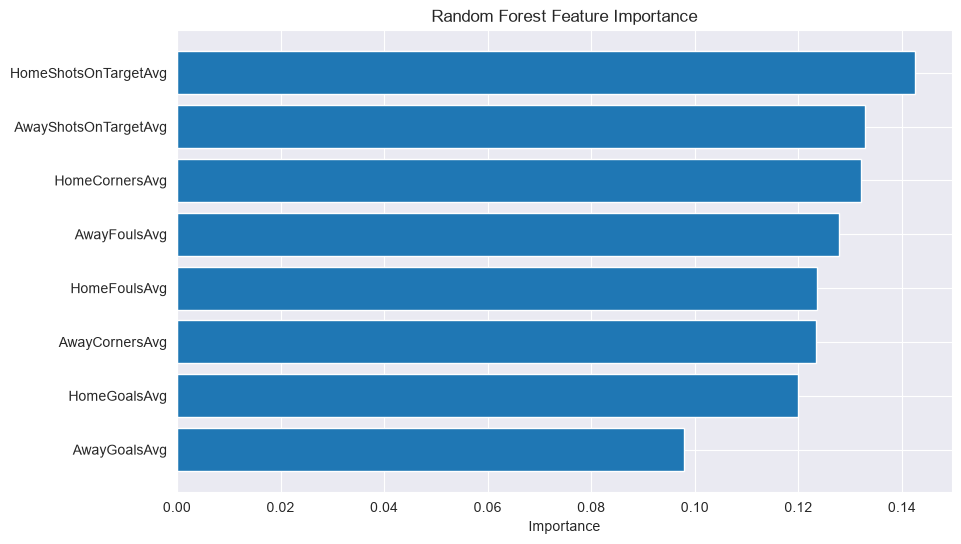

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

#feature loading and encoding
df = pd.read_csv("../data/processed/epl_features.csv")
features = ["HomeGoalsAvg", "AwayGoalsAvg", "HomeShotsOnTargetAvg", "AwayShotsOnTargetAvg", "HomeCornersAvg", "AwayCornersAvg", "HomeFoulsAvg", "AwayFoulsAvg"]
X = df[features]
y = df["FTR"]
encoder = LabelEncoder()
y = encoder.fit_transform(y)

#Setting up Model and variables
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
#Model training and testing
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(encoder.classes_)
print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions, zero_division=0))

#Feature importance
importance = pd.DataFrame({
    "Feature":features,
    "Importance":model.feature_importances_,
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

#Bar plot of feature importance
importance = importance.sort_values(
    by="Importance",
    ascending=True
)
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()